In [128]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [119]:
df = pd.read_csv('../Data/Data_finance_lab3_cleaned.csv')
featured_df = pd.read_csv('../Data/Data_finance_lab3_featured.csv')

In [120]:
featured_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   LOANAMOUNT_NOT_INSURANCE               5000 non-null   int64  
 1   INSURANCE_FEE                          5000 non-null   int64  
 2   LA                                     5000 non-null   int64  
 3   EFF_RATE                               5000 non-null   float64
 4   TERM                                   5000 non-null   int64  
 5   RESULT_YES/NO                          5000 non-null   int64  
 6   COUNT_TERM_RECEIPT                     5000 non-null   float64
 7   SUM_RECEIPT_AMT                        5000 non-null   float64
 8   EMI                                    5000 non-null   int64  
 9   GENDER                                 5000 non-null   int64  
 10  AGE                                    5000 non-null   int64  
 11  Numb

In [121]:
y = featured_df['RESULT_YES/NO']
featured_df = featured_df.drop(columns=['RESULT_YES/NO'])
print(featured_df.shape)
print(y.shape)

(5000, 35)
(5000,)


In [122]:
scaler = MinMaxScaler()
Data_norm = scaler.fit_transform(featured_df)
Data_norm = pd.DataFrame(Data_norm)
Data_norm.head()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,0.244186,0.257143,0.244249,0.529412,0.636364,0.52,0.178138,0.176634,0.0,0.148148,...,0.0,0.0,0.0,0.0,0.489965,0.404762,0.145042,0.230469,0.044014,0.554309
1,0.127907,0.142857,0.127979,0.523529,0.272727,0.56,0.163161,0.156389,0.0,0.086420,...,0.0,0.0,0.0,0.0,0.807787,0.095238,0.158394,0.218878,0.096831,0.554309
2,0.345930,0.357143,0.345984,0.552941,0.636364,0.48,0.230275,0.270057,1.0,0.037037,...,0.0,1.0,0.0,0.0,0.456023,0.428571,0.378107,0.191789,0.020246,0.554309
3,0.418605,0.428571,0.418653,0.523529,0.636364,0.44,0.227093,0.325811,0.0,0.135802,...,0.0,1.0,0.0,0.0,0.374768,0.452381,0.237354,0.211377,0.041373,0.554309
4,0.273256,0.285714,0.273316,0.523529,0.454545,0.52,0.238397,0.253725,1.0,0.061728,...,0.0,0.0,0.0,0.0,0.590133,0.261905,0.207379,0.215923,0.045775,0.554309


In [123]:
featured_df.head()

,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,COUNT_TERM_RECEIPT,SUM_RECEIPT_AMT,EMI,GENDER,AGE,...,EDUCATION_Master Degree,EDUCATION_Middle School,EDUCATION_No Education,EDUCATION_Working Cerfiticate,REPAYMENT_RATE,REMAINING_TERM,EXPENSE_INCOME_RATIO,INCOME,AGE_TERM_RATIO,INSURANCE_LOAN_RATIO
0,18000000,990000,18990000,45.0,24,12.0,14701000.0,1213820,0,30,...,0.0,0.0,0.0,0.0,0.774144,12.0,0.503448,14400000,1.250000,0.055
1,10000000,550000,10550000,44.5,12,13.0,13465000.0,1105184,0,25,...,0.0,0.0,0.0,0.0,1.276303,-1.0,0.546341,9300000,2.083333,0.055
2,25000000,1375000,26375000,47.0,24,11.0,19003625.0,1715125,1,21,...,0.0,1.0,0.0,0.0,0.720517,13.0,1.252167,-2618000,0.875000,0.055
3,30000000,1650000,31650000,44.5,24,10.0,18741000.0,2014302,0,29,...,0.0,1.0,0.0,0.0,0.592133,14.0,0.800000,6000000,1.208333,0.055
4,20000000,1100000,21100000,44.5,18,12.0,19673856.0,1627488,1,23,...,0.0,0.0,0.0,0.0,0.932410,6.0,0.703704,8000000,1.277778,0.055


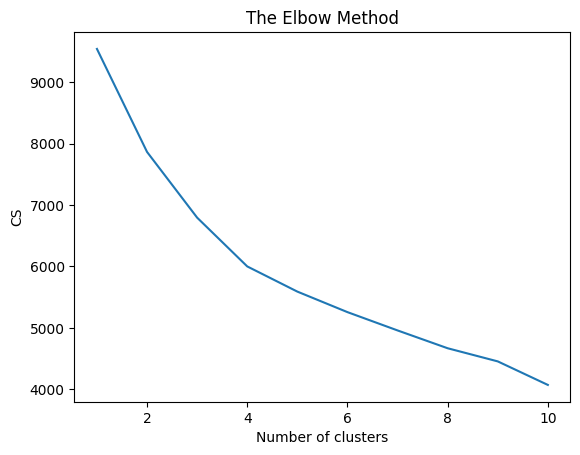

In [125]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(Data_norm)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')   
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [127]:
kmeans = KMeans(n_clusters=2,random_state=0)

kmeans.fit(Data_norm)

labels = kmeans.labels_
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.4f}'. format(correct_labels/float(y.size)))

Result: 2351 out of 5000 samples were correctly labeled.
Accuracy score: 0.4702


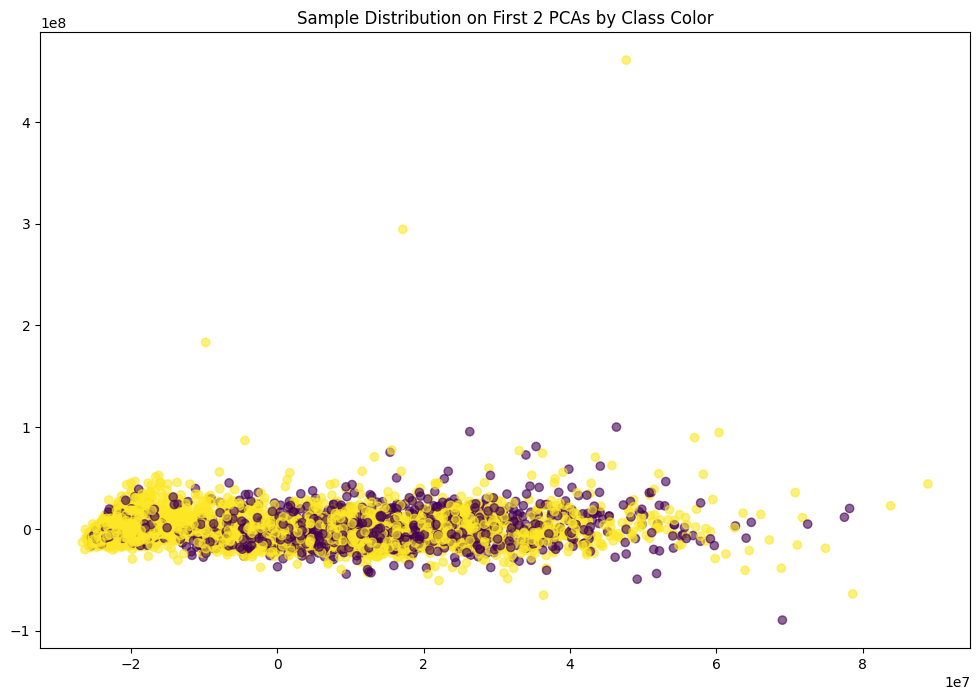

In [159]:
pca = PCA(2)
x_pca = pca.fit_transform(featured_df)
x_pca = pd.DataFrame(x_pca)
x_pca.columns = ['pc1', 'pc2']

plt.figure(figsize=(12,8))
plt.title('Sample Distribution on First 2 PCAs by Class Color')
plt.scatter(x_pca['pc1'], x_pca['pc2'], alpha = .6, c = y)
plt.show()